# FashionMNIST 服装图像分类——训练过程精细化控制

> **前置知识**：本 notebook 是 `1.image_classification.ipynb` 的**进阶篇**。
> 基础篇已覆盖：数据可视化、预处理与归一化、基础训练循环、学习曲线绘制。
> 本篇在此基础上，专注于**如何在训练过程中加入更多控制机制**，不再重复基础内容。

## 与基础篇的区别

| 对比维度 | 基础篇（notebook 01） | 本篇（notebook 02） |
|----------|----------------------|---------------------|
| 数据可视化 | ✅ 灰度图可视化 | ❌ 不涉及 |
| 数据预处理 | ✅ 详细讲解归一化 | 简略（已掌握） |
| 训练循环 | 手写基础版 | 封装为带回调的函数 |
| 模型保存 | ❌ 不涉及 | ✅ 自动保存最佳检查点 |
| 早停 | ❌ 不涉及 | ✅ EarlyStopCallback |
| 训练可视化 | 事后绘制学习曲线 | ✅ TensorBoard 实时监控 |

## 本篇内容概述

| 章节 | 内容 |
|------|------|
| 一、环境导入 | 导入所需第三方库 |
| 二、数据准备 | 加载 FashionMNIST 数据集，构建 DataLoader |
| 三、定义模型 | 搭建全连接神经网络 |
| 四、训练 | 评估函数、TensorBoard 回调、模型保存回调、早停回调、完整训练循环 |
| 五、模型评估 | 加载最佳检查点，评估模型性能 |

> **环境依赖**：TensorBoard 可视化只需安装 `tensorboard`，无需安装 tensorflow（tensorflow 不提供 Windows 原生包）：
> ```shell
> pip install tensorboard
> ```

## 一、环境导入

In [23]:
import matplotlib as mpl          # 导入 matplotlib 核心模块，用于图形配置（字体、颜色映射等全局参数）
import matplotlib.pyplot as plt   # 导入 pyplot 子模块，提供类似 MATLAB 的绘图接口（画折线图、散点图等）
%matplotlib inline                
# Jupyter 魔法命令：将图表直接嵌入 notebook 输出区域，无需 plt.show()
import numpy as np                # 导入 NumPy，提供高性能数值计算与多维数组操作，别名 np
import sklearn                    # 导入 scikit-learn，机器学习工具库（本项目用于计算准确率等评估指标）
import pandas as pd               # 导入 Pandas，提供 DataFrame 表格型数据处理与分析工具，别名 pd
import os                         # 导入 os 模块，提供操作系统交互接口（文件/目录创建、路径拼接等）
import sys                        # 导入 sys 模块，用于访问 Python 解释器信息（版本、路径等）
import time                       # 导入 time 模块，提供时间计量函数（如 time.time()）
from tqdm.auto import tqdm        # 从 tqdm 导入进度条工具；auto 会自动适配 notebook / 终端环境
import torch                      # 导入 PyTorch 深度学习框架核心库
import torch.nn as nn             # 导入神经网络模块，提供层（Linear、Conv2d 等）、损失函数等高层 API，别名 nn
import torch.nn.functional as F   # 导入函数式神经网络接口（激活函数、损失函数等无参数版本），别名 F

print(sys.version_info)           # 打印当前 Python 版本信息，返回 sys.version_info 对象（含 major/minor/micro 等字段）
for module in mpl, np, pd, sklearn, torch:  # 遍历各依赖库对象（iterable），逐一打印版本号
    print(module.__name__, module.__version__)  # __name__（str）：库名；__version__（str）：版本字符串

# 自动选择运算设备：优先使用 GPU（cuda:0），若无 GPU 则回退到 CPU
# torch.cuda.is_available()：返回 bool，True 表示系统中有可用的 CUDA GPU
# torch.device(str)：创建设备对象，参数为设备字符串，如 "cuda:0" 或 "cpu"
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印最终选用的设备，如 "cuda:0" 或 "cpu"


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

### 2.1 加载 FashionMNIST 数据集

In [24]:
from torchvision import datasets                    # 从 torchvision 导入数据集模块，包含 FashionMNIST、CIFAR10 等常见视觉数据集
from torchvision.transforms import ToTensor         # 导入 ToTensor 变换：将 PIL Image 或 ndarray 转为 FloatTensor，并将像素值归一化到 [0, 1]

# 加载 FashionMNIST 训练集
# datasets.FashionMNIST 参数说明：
#   root     (str):      数据集根目录，不存在时自动创建
#   train    (bool):     True → 加载训练集（60000 张），False → 加载测试集（10000 张）
#   download (bool):     True → 若本地不存在则自动从网络下载
#   transform(callable): 对原始 PIL 图像做预处理；ToTensor() 将图像转为形状 [1, 28, 28] 的 FloatTensor 并归一化到 [0, 1]
# 返回类型：torchvision.datasets.mnist.FashionMNIST（Dataset 子类）
train_ds = datasets.FashionMNIST(
    root="data",           # 数据存储根目录（相对路径，会在当前工作目录下创建 data/ 文件夹）
    train=True,            # 加载训练集（共 60000 张 28×28 灰度图像）
    download=True,         # 若本地不存在数据，则自动下载
    transform=ToTensor()   # 预处理：PIL Image [H=28, W=28] → FloatTensor [1, 28, 28]，像素值归一化到 [0, 1]
)

# 加载 FashionMNIST 测试集（本项目中将其作为验证集使用）
# 参数与训练集相同，仅 train=False 不同
test_ds = datasets.FashionMNIST(
    root="data",           # 与训练集共用同一数据目录
    train=False,           # 加载测试集（共 10000 张图像）
    download=True,         # 若本地不存在数据，则自动下载
    transform=ToTensor()   # 同上，图像转为 FloatTensor 并归一化
)

# 注意：torchvision 数据集里没有提供训练集和验证集的划分
# 用 torch.utils.data.random_split 实现人为划分
from torch.utils.data import random_split  # 补充导包

# 用 random_split 从原训练集中划分训练集和验证集（例如 80% 作为训练、20% 作为验证）
# 计算训练集总长度（样本数量），即原始 train_ds 的总数（60000）
total_len = len(train_ds)         

# 按 80% 比例计算划分后训练集的长度
train_len = int(0.8 * total_len)  

# 剩下 20% 作为验证集，其长度为总长度减去训练集长度
val_len = total_len - train_len   

# 用 random_split 将原 train_ds 分为新的训练集和验证集（80%/20%划分）
train_ds, val_ds = random_split(train_ds, [train_len, val_len])

### 2.2 查看数据类型、创建 DataLoader 并预览形状

In [25]:
type(train_ds)   # 查看 train_ds 的数据类型；返回 torchvision.datasets.mnist.FashionMNIST 类对象

torch.utils.data.dataset.Subset

In [26]:
# 从数据集构建 DataLoader，用于按批次迭代数据
# torch.utils.data.DataLoader 常用参数说明：
#   dataset    (Dataset): 数据集对象（实现了 __len__ 和 __getitem__ 的类）
#   batch_size (int):     每个批次包含的样本数量，此处为 32
#   shuffle    (bool):    是否在每个 epoch 开始时随机打乱数据顺序
#                         训练集设 True 以提升泛化，验证集设 False 保持顺序一致
# 返回类型：torch.utils.data.DataLoader（可迭代对象，每次迭代返回 (images, labels) 元组）
# 构建训练集 DataLoader
train_loader = torch.utils.data.DataLoader(
    train_ds,               # 数据集对象，80%原始训练集（已拆分）
    batch_size=32,          # 每个批次32个样本
    shuffle=True,           # 每个epoch前随机打乱样本顺序，提高训练泛化能力
    num_workers=4           # 启用4个子进程辅助数据读取，提高加载速度（可根据CPU核数调整）
)   # 训练集 DataLoader：32个样本/批，打乱顺序

# 设置验证集 DataLoader 的随机生成器，用于保证划分和排序的可复现性
g = torch.Generator()       # 创建新的随机数生成器
g.manual_seed(36)          # 固定随机种子，保证每次划分和迭代顺序一致

# 构建验证集 DataLoader
val_loader = torch.utils.data.DataLoader(
    val_ds,                 # 验证集对象（20%原始训练集）
    batch_size=64,          # 每个批次64个样本；加速推理
    shuffle=False,          # 不打乱顺序，便于模型评估可复现
    generator=g,            # 指定随机生成器，指定生成器，保证批处理划分稳定
    num_workers=4           # 多进程读取，提升速度；加速推理
)  # 验证集 DataLoader：64个样本/批，不打乱顺序，随机种子固定

# 创建测试集 DataLoader 的随机生成器，区别于验证集，种子不同确保独立性
g = torch.Generator()
g.manual_seed(42)          # 再次固定种子，用于测试集（确保可复现）

# 构建测试集 DataLoader
test_loader = torch.utils.data.DataLoader(
    test_ds,                # 测试集对象（官方10000张图片）
    batch_size=64,          # 每批64个样本；加速推理
    shuffle=False,          # 不打乱顺序，便于逐步评估和与原始标签对齐
    generator=g,            # 指定生成器，保证批处理划分稳定
    num_workers=4           # 多进程加速数据预取；加速推理
)

In [27]:
# 查看训练集 DataLoader 中第一个批次的数据张量形状
for datas, labels in train_loader:
    # datas：图像张量，形状 [batch_size, channels, H, W] = [32, 1, 28, 28]
    #   batch_size=32：一个批次 32 张图片
    #   channels=1：灰度图（FashionMNIST 是单通道灰度图像）
    #   H=28, W=28：每张图片高度和宽度均为 28 像素
    print(datas.shape)    # 输出：torch.Size([32, 1, 28, 28])
    # labels：标签张量，形状 [batch_size] = [32]
    #   每个元素为 0~9 的整数，对应10个服装类别（如 T-shirt=0, Trouser=1, ...）
    print(labels.shape)   # 输出：torch.Size([32])
    break  # 仅查看第一个批次，break 提前退出循环，避免遍历整个数据集

# 查看验证集 DataLoader 中第一个批次的数据张量形状
for datas, labels in val_loader:
    print(datas.shape)    # 与训练集相同：torch.Size([32, 1, 28, 28])
    print(labels.shape)   # 与训练集相同：torch.Size([32])
    break  # 仅查看第一个批次

torch.Size([32, 1, 28, 28])
torch.Size([32])
torch.Size([64, 1, 28, 28])
torch.Size([64])


## 三、定义模型

### 3.1 定义神经网络模型（NeuralNetwork）

In [28]:
# 定义神经网络模型类，继承 nn.Module（PyTorch 中所有神经网络的基类）
class NeuralNetwork(nn.Module):
    def __init__(self):
        # 必须调用父类 nn.Module 的初始化方法，完成内部状态初始化
        super().__init__()

        # nn.Flatten()：将多维输入张量展平为 1D 向量（保留 batch 维度不变）
        #   默认 start_dim=1，即从第1维开始展平（跳过 batch 维）
        #   输入形状 [batch, 1, 28, 28] → 输出形状 [batch, 784]（1×28×28 = 784）
        self.flatten = nn.Flatten()

        # nn.Sequential：顺序容器，按定义顺序逐层执行前向传播，上一层输出自动传给下一层
        self.linear_relu_stack = nn.Sequential(
            # 全连接层1：输入特征维度 784（28×28），输出特征维度 300
            # in_features  (int): 输入神经元数 = 784
            # out_features (int): 输出神经元数 = 300
            # 权重矩阵形状 [300, 784]，偏置形状 [300]
            nn.Linear(28 * 28, 300),

            # ReLU 激活函数：f(x) = max(0, x)，将负值置为0，引入非线性
            # 形状不变：[batch, 300] → [batch, 300]
            nn.ReLU(),

            # 全连接层2：输入维度 300 → 输出维度 100
            # 权重矩阵形状 [100, 300]，偏置形状 [100]
            nn.Linear(300, 100),

            # 再次使用 ReLU 激活函数，引入非线性
            nn.ReLU(),

            # 全连接层3（输出层）：输入维度 100 → 输出维度 10（对应10个服装类别）
            # 权重矩阵形状 [10, 100]，偏置形状 [10]
            # 输出为未经 softmax 的原始分数（logits）
            nn.Linear(100, 10),
        )

    def forward(self, x):
        """
        前向传播方法：定义输入数据从输入层到输出层的完整计算流程。

        参数：
            x (Tensor): 输入张量，形状 [batch_size, 1, 28, 28]
        返回：
            logits (Tensor): 输出张量，形状 [batch_size, 10]，未经 softmax 的类别分数
        """
        # 展平操作：[batch_size, 1, 28, 28] → [batch_size, 784]
        x = self.flatten(x)

        # 经过全连接网络（3层 Linear + 2层 ReLU）：[batch_size, 784] → [batch_size, 10]
        logits = self.linear_relu_stack(x)

        # 返回形状为 [batch_size, 10] 的 logits 张量（原始预测分数，未归一化）
        return logits

# 实例化神经网络模型，此时所有参数按 PyTorch 默认策略（Kaiming 均匀分布）随机初始化
model = NeuralNetwork()

## 四、训练

PyTorch 的训练流程需要手动实现，本节依次完成以下步骤：

1. 定义评估函数
2. 定义各类训练回调（TensorBoard 可视化、模型保存、早停）
3. 构建完整训练循环函数
4. 实例化模型、损失函数与优化器
5. 执行训练并查看结果

### 4.1 评估函数（evaluate）

In [29]:
from sklearn.metrics import accuracy_score   # 从 sklearn 导入准确率计算函数；accuracy_score(y_true, y_pred) → float（0.0 ~ 1.0）

# @torch.no_grad() 装饰器：在推理/验证阶段禁用梯度追踪
#   作用：减少显存占用并加速计算，因为验证阶段不需要执行反向传播
#   被装饰的函数内所有 tensor 操作均不会构建计算图
@torch.no_grad()
def evaluating(model, dataloader, loss_fct,optimizer):
    """
    在给定数据集上评估模型性能，计算平均损失和准确率。

    参数：
        model      (nn.Module):   待评估的 PyTorch 模型，需已调用 model.eval()
        dataloader (DataLoader):  数据加载器，每次迭代返回 (datas, labels) 元组
        loss_fct   (callable):    损失函数对象，如 nn.CrossEntropyLoss()

    返回：
        tuple(float, float): (所有批次的平均损失, 整个数据集的准确率)
    """
    model.eval()  # 切换到评估模式（停用 Dropout、BatchNorm，确保推理过程一致且无随机性，通常在验证/测试阶段调用）
    optimizer.zero_grad(set_to_none=True)   # 释放残余梯度，释放显存空间；set_to_none=True 释放显存，提高推理阶段的显存利用率
    loss_list  = []   # 存储每个 batch 的损失标量值，类型 list[float]
    pred_list  = []   # 存储每个 batch 所有样本的预测类别，类型 list[int]
    label_list = []   # 存储每个 batch 所有样本的真实标签，类型 list[int]

    for datas, labels in dataloader:
        # datas.shape:  [batch_size, 1, 28, 28] — 一批图像张量
        # labels.shape: [batch_size]             — 一批真实类别索引（整数，0~9）
        datas  = datas.to(device)    # 将图像张量从 CPU 转移到目标设备（GPU/CPU）
        labels = labels.to(device)   # 将标签张量从 CPU 转移到目标设备

        # 前向传播：将图像输入模型，得到每个类别的原始预测分数（logits）
        logits = model(datas)        # logits.shape: [batch_size, 10]，未经 softmax

        # 计算当前批次的交叉熵损失，返回标量 tensor（batch 内所有样本损失的均值）
        loss = loss_fct(logits, labels)

        # tensor.item()：将单元素 tensor 转换为 Python float，方便列表存储
        loss_list.append(loss.item())

        # argmax(axis=-1)：对最后一个维度（类别维度，dim=1）取最大值的索引
        #   即对每个样本的 10 个类别分数找到最大值对应的类别
        #   preds.shape: [batch_size]，每个元素为 0~9 的预测类别索引
        preds = logits.argmax(axis=-1)

        # 将预测结果从 GPU 转回 CPU，再转为 numpy array，最后转为 Python list 追加
        pred_list.extend(preds.cpu().numpy().tolist())
        # 将真实标签同样转回 CPU 并追加到列表中
        label_list.extend(labels.cpu().numpy().tolist())

    # 计算整个数据集上的分类准确率
    # accuracy_score(y_true, y_pred)：返回 float，正确预测样本数 / 总样本数
    acc = accuracy_score(label_list, pred_list)

    # 返回：(所有 batch 损失的算术平均值(float), 整个数据集的分类准确率(float))
    return np.mean(loss_list), acc


### 4.2 TensorBoard 可视化回调（TensorBoardCallback）

**安装依赖**（在管理员模式下执行）：

```shell
pip install tensorboard
```

> **注意**：TensorBoard 是独立包，**无需安装 tensorflow**。tensorflow 自 2.11 起不提供 Windows 原生包，在 Windows 上直接 `pip install tensorflow` 会报错，但 TensorBoard 本身可在 Windows 上正常使用。

**启动 TensorBoard 服务**（注意使用绝对路径，否则会报错）：

```shell
tensorboard --logdir="./tensorboard_logs" --host 0.0.0.0 --port 8848
```

> 提示：在命令行执行 `where tensorboard` 可确认 tensorboard 是否已正确安装并加入环境变量。

**启动后在浏览器访问**：

- http://localhost:8848
- 或 http://127.0.0.1:8848

In [30]:
from torch.utils.tensorboard import SummaryWriter   # 导入 TensorBoard 写入器，用于将训练指标写入日志文件，再由 tensorboard 服务读取并可视化


class TensorBoardCallback:
    """
    TensorBoard 可视化回调类。
    在训练循环中被调用，将损失、准确率、学习率等指标实时写入 TensorBoard 日志。
    """

    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoardCallback，创建 SummaryWriter。

        参数：
            log_dir    (str): TensorBoard 日志文件保存目录，如 "runs"
                              启动 tensorboard 时通过 --logdir 指定此路径
            flush_secs (int, optional): 每隔多少秒将缓冲区数据刷新写入磁盘，默认 10 秒
        """
        # SummaryWriter：TensorBoard 的核心写入对象
        #   log_dir    (str): 日志存放路径
        #   flush_secs (int): 自动刷新到磁盘的时间间隔（秒）
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard（Graphs 面板可视化）。

        参数：
            model       (nn.Module): 要可视化结构的模型
            input_shape (list):      单个输入样本的形状列表，如 [1, 28, 28]（不含 batch 维度）
        """
        # add_graph：对模型执行一次虚拟前向传播，追踪并记录计算图
        #   model           (nn.Module): 待可视化的模型
        #   input_to_model  (Tensor):    用于触发前向传播的虚拟输入张量
        # torch.randn(input_shape)：生成服从标准正态分布的随机张量，形状由 input_shape 决定
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """
        将训练损失和验证损失写入 TensorBoard（同一折线图显示两条曲线）。

        参数：
            step     (int):   当前全局训练步数，作为 x 轴坐标
            loss     (float): 当前批次的训练损失值
            val_loss (float): 当前验证集的平均损失值
        """
        # add_scalars：在同一图表中绘制多条折线曲线
        #   main_tag        (str):  图表路径名（TensorBoard 中的分组名称）
        #   tag_scalar_dict (dict): 子曲线名称 → 数值 的映射字典
        #   global_step     (int):  当前步数，决定 x 轴位置
        self.writer.add_scalars(
            main_tag="training/loss",                              # 图表路径："training" 组下的 "loss" 图
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 同时记录训练损失和验证损失
            global_step=step,                                      # 当前训练步数（x 轴）
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """
        将训练准确率和验证准确率写入 TensorBoard。

        参数：
            step    (int):   当前全局训练步数
            acc     (float): 当前批次的训练准确率（0.0 ~ 1.0）
            val_acc (float): 当前验证集的准确率（0.0 ~ 1.0）
        """
        # 与 add_loss_scalars 逻辑相同，将准确率曲线写入 TensorBoard
        self.writer.add_scalars(
            main_tag="training/accuracy",                               # 图表路径："training" 组下的 "accuracy" 图
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc}, # 同时记录训练和验证准确率
            global_step=step,                                           # 当前训练步数（x 轴）
        )

    def add_lr_scalars(self, step, learning_rate):
        """
        将当前学习率写入 TensorBoard，便于监控学习率调度效果。

        参数：
            step          (int):   当前全局训练步数
            learning_rate (float): 当前优化器使用的学习率值
        """
        # 记录学习率随训练步数的变化曲线
        self.writer.add_scalars(
            main_tag="training/learning_rate",                    # 图表路径："training" 组下的 "learning_rate" 图
            tag_scalar_dict={"learning_rate": learning_rate},     # 当前学习率值
            global_step=step,                                     # 当前训练步数（x 轴）
        )

    def __call__(self, step, **kwargs):
        """
        使实例可以像函数一样被调用，统一调度各项指标的记录操作。

        参数：
            step     (int):  当前全局训练步数
            **kwargs (dict): 可包含以下关键字参数：
                             loss     (float): 训练损失
                             val_loss (float): 验证损失
                             acc      (float): 训练准确率
                             val_acc  (float): 验证准确率
                             lr       (float): 当前学习率
        """
        # kwargs.pop(key, default)：从 kwargs 中取出并删除 key 对应的值
        #   若 key 不存在则返回 default（此处为 None），避免 KeyError

        # 取出损失相关参数并记录
        loss     = kwargs.pop("loss",     None)   # 训练损失，类型 float | None
        val_loss = kwargs.pop("val_loss", None)   # 验证损失，类型 float | None
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)   # 两者都存在才写入损失曲线

        # 取出准确率相关参数并记录
        acc     = kwargs.pop("acc",     None)     # 训练准确率，类型 float | None
        val_acc = kwargs.pop("val_acc", None)     # 验证准确率，类型 float | None
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)      # 两者都存在才写入准确率曲线

        # 取出学习率参数并记录
        learning_rate = kwargs.pop("lr", None)    # 当前学习率，类型 float | None
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)      # 存在则写入学习率曲线


### 4.3 保存最佳模型（SaveCheckpointsCallback）

In [31]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调类。
    按照训练步数定期保存模型权重，支持"仅保存最佳模型"和"每步保存"两种策略。

    实际工程中通常按 step 而非 epoch 来评估和保存模型，本类实现了此策略。
    """

    def __init__(self, save_dir, save_step=500, save_best_only=True):
        """
        初始化 SaveCheckpointsCallback。

        参数：
            save_dir      (str):  检查点文件的保存目录，不存在时自动创建
            save_step     (int):  每隔多少训练步执行一次保存检查，默认 500 步
            save_best_only(bool): 保存策略：
                                  True  → 只保存验证指标最好的模型（覆盖 best.ckpt）
                                  False → 每次到保存步时均生成新文件（格式：{step}.ckpt）
        """
        self.save_dir      = save_dir         # 检查点保存目录（str）
        self.save_step     = save_step        # 保存间隔步数（int）
        self.save_best_only = save_best_only  # 是否只保存最佳模型（bool）

        # 历史最佳指标值（float），初始化为 -1
        # 由于准确率范围是 [0, 1]，-1 可确保第一次评估时必然保存模型
        self.best_metrics = -1

        # 若指定目录不存在，则自动创建
        # os.path.exists(path)：检查路径是否存在，返回 bool
        # os.mkdir(path)：创建单级目录（父目录必须已存在）
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        每次训练步调用此方法，判断是否需要保存当前模型。

        参数：
            step       (int):          当前全局训练步数
            state_dict (OrderedDict):  模型参数字典，通过 model.state_dict() 获取；
                                       键为参数名（str），值为对应的参数张量（Tensor）
            metric     (float | None): 用于比较的验证指标（如验证准确率）；
                                       save_best_only=True 时必须提供，否则会触发断言错误
        """
        # 只在 save_step 的整数倍步数时执行保存，其余步直接跳过
        # step % save_step > 0 表示当前步不是 save_step 的倍数
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            # save_best_only=True 时必须传入 metric，否则无法比较是否是最佳模型
            assert metric is not None, 'metric is not None'   # 断言 metric 不能为 None

            if metric >= self.best_metrics:   # 当前指标优于或等于历史最佳时才保存
                # torch.save(obj, path)：将 Python 对象（state_dict）序列化保存到指定路径
                # 注意：这里只保存模型参数（state_dict），不保存优化器状态和 epoch/step 信息
                # 文件名固定为 best.ckpt，新的最佳模型会覆盖旧文件
                # 保存当前最佳模型参数到 "best.ckpt" 文件（每次有更优模型时会覆盖旧文件）
                # os.path.join(self.save_dir, "best.ckpt")：将保存目录和文件名智能拼接为完整路径，适配不同操作系统（如 Windows、Linux、MacOS）
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
         
         
                self.best_metrics = metric    # 更新历史最佳指标值
        else:
            # save_best_only=False 时，每次到达保存步均保存一个新文件
            # 文件名包含当前步数，格式为 "{step}.ckpt"，不会覆盖之前的文件
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


### 4.4 早停回调（EarlyStopCallback）

In [32]:
class EarlyStopCallback:
    """
    早停回调类（Early Stopping）。

    当验证指标在连续多个评估步内不再显著提升时，发出停止训练的信号。
    早停的作用：防止模型在训练集上过拟合，同时节省计算资源和时间。
    """

    def __init__(self, patience=5, min_delta=0.01):
        """
        初始化 EarlyStopCallback。

        参数：
            patience  (int,   optional): 容忍的最大"不提升"连续评估次数；
                                         超过此次数后 early_stop 属性返回 True，训练应停止。
                                         默认为 5 次。
            min_delta (float, optional): 判定"有效提升"的最小阈值；
                                         当前指标 - 历史最佳指标 < min_delta 时视为无提升。
                                         默认为 0.01（即准确率需至少提升 1% 才算有效）。
        """
        self.patience   = patience    # 最大容忍次数（int），超过后触发早停
        self.min_delta  = min_delta   # 最小有效提升幅度（float）
        self.best_metric = -1         # 历史最佳指标值（float），初始化为 -1（低于任何正常准确率）
        self.counter    = 0           # 连续不提升次数计数器（int），每次有效提升时重置

    def __call__(self, metric):
        """
        每次验证结束后调用此方法，更新早停状态。

        参数：
            metric (float): 当前评估步获得的验证指标（如验证集准确率）
        """
        # 判断本次指标相较历史最佳是否有显著提升
        # 需满足：metric >= best_metric + min_delta（提升幅度超过最小阈值）
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric   # 更新历史最佳指标为当前值
            self.counter = 0            # 重置计数器：出现有效提升，重新从0开始计数
        else:
            # 本次无显著提升，计数器自增
            self.counter += 1           # 连续不提升次数 +1，累计到 patience 时触发早停

    @property   # @property 装饰器：将方法包装为只读属性，访问时无需括号（obj.early_stop 而非 obj.early_stop()）
    def early_stop(self):
        """
        只读属性：判断是否应触发早停。

        返回：
            bool: True  → 连续不提升次数已达到 patience，应立即停止训练
                  False → 还未达到容忍上限，继续训练
        """
        return self.counter >= self.patience   # 计数器 >= 容忍次数时返回 True


### 4.5 早停触发时机估算

In [33]:
# 估算早停可能触发时已处理的样本总量
# 公式：每次评估间隔步数(eval_step) × 每批样本数(batch_size) × 早停容忍次数(patience)
# 以 eval_step=500、batch_size=32、patience=5 为例：
# 含义：经过约 80000 个样本的训练后，若验证准确率仍无显著提升，则触发早停
500 * 32 * 5   # 结果：80000，即约处理 8 万个样本后早停可能触发

80000

### 4.6 完整训练循环函数（training）

In [34]:
# 完整训练函数：集成了 TensorBoard 可视化、检查点保存、早停三种回调机制
def training(
    model,                          # nn.Module:    待训练的神经网络模型
    train_loader,                   # DataLoader:   训练集数据加载器
    val_loader,                     # DataLoader:   验证集数据加载器
    epoch,                          # int:          训练总轮数（最大 epoch 数）
    loss_fct,                       # callable:     损失函数对象，如 nn.CrossEntropyLoss()
    optimizer,                      # Optimizer:    优化器对象，如 torch.optim.SGD
    tensorboard_callback=None,      # TensorBoardCallback | None: TensorBoard 可视化回调，为 None 时跳过
    save_ckpt_callback=None,        # SaveCheckpointsCallback | None: 检查点保存回调，为 None 时跳过
    early_stop_callback=None,       # EarlyStopCallback | None: 早停回调，为 None 时跳过
    eval_step=500,                  # int: 每隔多少训练步在验证集上评估一次，默认 500 步
):
    # 初始化训练记录字典，存储训练集和验证集的各步指标
    record_dict = {
        "train": [],   # list[dict]: 每条记录格式 {"loss": float, "acc": float, "step": int}
        "val":   []    # list[dict]: 每条记录格式 {"loss": float, "acc": float, "step": int}
    }

    global_step = 0       # int: 全局训练步数计数器，跨 epoch 持续累加（不随 epoch 重置）
    model.train()         # 切换模型为训练模式：启用 Dropout、BatchNorm 使用当前批统计量等

    # tqdm 进度条：total 为训练总步数 = epoch 数 × 每轮批次数
    with tqdm(total=epoch * len(train_loader)) as pbar:

        for epoch_id in range(epoch):   # 遍历每个 epoch，epoch_id 从 0 到 epoch-1

            # ===== 训练阶段 =====
            for datas, labels in train_loader:   # 按批次迭代训练集
                datas  = datas.to(device)         # 将图像张量转移到目标设备（GPU/CPU）
                labels = labels.to(device)        # 将标签张量转移到目标设备

                # 梯度清零：PyTorch 默认会累积梯度，每次反向传播前必须手动清零
                optimizer.zero_grad()

                # 前向传播：将输入数据传入模型，计算各类别的原始预测分数
                logits = model(datas)             # logits.shape: [batch_size, 10]

                # 计算损失：比较 logits 与真实标签，返回标量 tensor（当前批次的平均交叉熵损失）
                loss = loss_fct(logits, labels)

                # 反向传播：根据损失自动计算各参数的梯度，存储在 param.grad 属性中
                loss.backward()

                # 参数更新：优化器根据梯度和学习率更新模型中所有可学习参数
                # SGD 更新公式：W = W - lr × grad（含动量项）
                optimizer.step()

                # 取每个样本预测概率最大的类别索引
                preds = logits.argmax(axis=-1)    # preds.shape: [batch_size]，元素为 0~9 的整数

                # 计算当前批次的训练准确率（需先将 tensor 移到 CPU 再转 numpy）
                acc  = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())   # float: 0.0 ~ 1.0
                loss = loss.cpu().item()          # 将标量 tensor 转为 Python float

                # 记录当前步的训练指标
                record_dict["train"].append({
                    "loss": loss,          # 当前批次训练损失（float）
                    "acc":  acc,           # 当前批次训练准确率（float）
                    "step": global_step    # 当前全局步数（int）
                })

                # ===== 定期验证阶段（每隔 eval_step 步执行一次）=====
                if global_step % eval_step == 0:

                    # 在验证集上计算平均损失和准确率（@torch.no_grad() 内部不计算梯度）
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct,optimizer)

                    # 记录当前验证步的指标
                    record_dict["val"].append({
                        "loss": val_loss,      # 验证集平均损失（float）
                        "acc":  val_acc,       # 验证集准确率（float）
                        "step": global_step    # 触发验证时的全局步数（int）
                    })
                    model.train()  # 验证结束后切换回训练模式

                    # 回调1：TensorBoard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,                          # x 轴：当前步数
                            loss=loss,     val_loss=val_loss,     # 训练损失和验证损失
                            acc=acc,       val_acc=val_acc,       # 训练准确率和验证准确率
                            lr=optimizer.param_groups[0]["lr"],   # 从优化器的参数组中取出当前学习率（float）
                        )

                    # 回调2：保存模型检查点
                    if save_ckpt_callback is not None:
                        # 传入：全局步数（决定是否到保存时机）、模型参数字典、验证准确率（决定是否为最佳）
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 回调3：早停判断
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)           # 更新早停状态（有效提升则重置计数器，否则 +1）
                        if early_stop_callback.early_stop:     # 若连续不提升次数已达 patience，触发早停
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict   # 提前终止训练，返回已记录的所有指标数据

                # 每处理完一个批次，全局步数加1
                global_step += 1
                pbar.update(1)                           # 进度条前进1步
                pbar.set_postfix({"epoch": epoch_id})    # 在进度条后方显示当前 epoch 编号

    # 所有 epoch 训练完成后返回完整的训练记录字典
    return record_dict

### 4.7 实例化模型、损失函数、优化器与各回调

In [35]:
epoch = 100   # int: 最大训练轮数，由于配置了早停回调，实际训练轮数通常远少于100

# 重新实例化模型，确保从随机初始化的参数开始本次训练
model = NeuralNetwork()

# 1. 定义损失函数
# nn.CrossEntropyLoss：交叉熵损失，内部自动完成 LogSoftmax + NLLLoss 两步操作
# 适用于多分类任务：输入为未归一化的 logits（[batch, num_classes]），目标为类别索引（[batch]）
# nn.CrossEntropyLoss 用于多分类任务的损失函数，常用参数说明：
#   weight=None：类别权重（tensor，形状[num_classes]），用于处理类别不平衡问题，None 表示各类等权
#   ignore_index=-100：忽略指定类别标签的数据样本，其损失不参与反向传播
#   reduction="mean"：对 batch 内损失的聚合方法，"mean"（默认，对所有样本取均值）、"sum"（总和）、"none"（逐样本返回）
loss_fct = nn.CrossEntropyLoss()

# 2. 定义优化器（SGD with momentum）
# torch.optim.SGD 参数说明：
#   params   (iterable): 模型可学习参数的生成器，通过 model.parameters() 获取
#   lr       (float):    学习率，控制每次参数更新的步长大小，此处为 0.001
#   momentum (float):    动量系数（经典值 0.9），加速收敛并抑制梯度方向的震荡
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 3. 实例化 TensorBoard 可视化回调
# log_dir="tensorboard_logs"：TensorBoard 日志文件保存在当前目录下的 tensorboard_logs/ 文件夹
tensorboard_callback = TensorBoardCallback("tensorboard_logs")
# draw_model：向 TensorBoard 写入模型计算图
# 参数 [1, 28, 28] 为单个输入样本的形状（不含 batch 维度）：1 个通道，28×28 像素
tensorboard_callback.draw_model(model, [1, 28, 28])

# 4. 实例化检查点保存回调
# save_dir="checkpoints"：检查点文件保存在 checkpoints/ 目录
# save_best_only=True：只保存验证准确率最高的模型，文件名固定为 best.ckpt
save_ckpt_callback = SaveCheckpointsCallback("checkpoints", save_best_only=True)

# 5. 实例化早停回调
# patience=5：若连续 5 次验证（每隔 eval_step 步评估一次）验证准确率均无显著提升，则停止训练
early_stop_callback = EarlyStopCallback(patience=5)


### 4.8 查看模型参数与 state_dict 结构

In [36]:
# 查看模型某一层的可学习参数（Parameter 对象）
# model.parameters()：生成器，按层定义顺序依次返回所有可学习参数
#   index=0 → linear_relu_stack.0.weight，形状 [300, 784]（第一个全连接层的权重矩阵）
#   index=1 → linear_relu_stack.0.bias，  形状 [300]（第一个全连接层的偏置向量）
#   index=2 → linear_relu_stack.2.weight，形状 [100, 300]
#   ...以此类推
# list(...)[1]：将生成器转为列表，取第2个元素（index=1），即第一层的偏置参数
# 返回类型：nn.Parameter（带 requires_grad=True 的可求梯度 tensor），形状 [300]
list(model.parameters())[1]   # 查看第一个全连接层（784→300）的偏置参数（bias），形状 [300]

Parameter containing:
tensor([-1.1218e-02,  2.4520e-03,  1.3496e-02,  1.2507e-02,  1.5234e-02,
         1.8862e-02, -3.3006e-02,  2.6759e-02,  3.3785e-03, -1.1213e-02,
         3.1411e-02, -1.8553e-02, -2.8963e-02, -8.6469e-03,  1.6769e-04,
         1.4633e-02,  1.2845e-02, -1.0259e-03, -1.7902e-02, -3.0626e-02,
         3.1131e-02,  3.8425e-03, -1.1826e-02, -1.5153e-02, -3.2198e-02,
        -2.9655e-02, -3.2439e-02,  1.6665e-04,  2.2996e-02,  3.1397e-02,
         1.1639e-02, -4.4470e-03, -1.7918e-03, -2.0677e-03,  1.6423e-02,
        -2.7699e-02, -2.7350e-02, -6.2955e-03, -2.3231e-02, -5.0978e-03,
        -2.1929e-02,  9.8421e-03,  3.9640e-03,  1.8820e-02,  2.4959e-02,
         1.6852e-02, -1.9065e-02,  2.1895e-02,  1.9980e-02,  1.2472e-02,
        -1.9543e-02,  1.6737e-02, -1.9309e-02, -9.9822e-03,  3.1836e-02,
         6.5873e-03, -1.6415e-02,  1.9012e-02, -2.8860e-02, -1.1666e-02,
        -3.4095e-02, -3.3579e-02, -3.4411e-02,  2.2112e-02, -1.3053e-02,
         1.2797e-02, -2.0854e

In [37]:
# 查看模型所有可学习参数的名称（键名）
# model.state_dict()：返回 OrderedDict（有序字典），键（str）为参数名，值（Tensor）为参数数据
# .keys()：返回所有参数名称的视图（odict_keys 类型）
# 命名规则：{模块路径}.{参数类型}
#   "linear_relu_stack.0.weight" → linear_relu_stack 中第0个子模块（nn.Linear(784,300)）的权重
#   "linear_relu_stack.0.bias"   → 第0个 nn.Linear 的偏置
#   "linear_relu_stack.2.weight" → 第2个子模块（nn.Linear(300,100)）的权重（索引1是ReLU，无参数）
#   以此类推（ReLU 无可学习参数，因此编号跳过奇数）
model.state_dict().keys()   # 返回 odict_keys，包含所有可学习参数的名称列表

odict_keys(['linear_relu_stack.0.weight', 'linear_relu_stack.0.bias', 'linear_relu_stack.2.weight', 'linear_relu_stack.2.bias', 'linear_relu_stack.4.weight', 'linear_relu_stack.4.bias'])

### 4.9 执行训练

In [38]:
# 将模型参数转移到目标设备（GPU 或 CPU）
# model.to(device)：将模型所有参数和缓冲区移动到指定设备，返回移动后的模型对象（原地操作）
model = model.to(device)

# 调用 training 函数开始训练，传入模型、数据、超参数和全部三个回调
# 返回：record_dict (dict)，包含 "train" 和 "val" 两个键，
#         分别对应训练集和验证集的步级指标记录列表 list[dict]
record = training(
    model,                                          # 已移至目标设备的模型
    train_loader,                                   # 训练集 DataLoader
    val_loader,                                     # 验证集 DataLoader
    epoch,                                          # 最大训练轮数（100）
    loss_fct,                                       # 损失函数：CrossEntropyLoss
    optimizer,                                      # 优化器：SGD（lr=0.001，momentum=0.9）
    tensorboard_callback=tensorboard_callback,      # TensorBoard 可视化回调
    save_ckpt_callback=save_ckpt_callback,          # 最佳模型检查点保存回调
    early_stop_callback=early_stop_callback,        # 早停回调（patience=5）
    eval_step=1000                                  # 每隔 1000 步在验证集上评估一次
)
# 注意：若进度条未显示，可能是 PyCharm 内置 Jupyter 的兼容性问题，在 JupyterLab 中可正常显示

  0%|          | 0/150000 [00:00<?, ?it/s]

Early stop at epoch 12 / global_step 19000


### 4.10 Python 补充：enumerate() 用法示例

In [39]:
# Python 内置函数 enumerate() 使用示例
# enumerate(iterable, start=0)：
#   iterable (iterable): 任意可迭代对象（列表、元组、字符串等）
#   start    (int):      起始索引值，默认 0
# 返回：enumerate 对象，每次迭代返回 (index, value) 元组
# 在 training 函数中用于同时获取批次索引和对应数据，非常常用

for i, item in enumerate(["a", "b", "c"]):   # 遍历列表，i 为自动生成的索引，item 为对应元素值
    print(i, item)   # 依次打印："0 a"、"1 b"、"2 c"

0 a
1 b
2 c


### 4.11 查看训练与验证记录

In [40]:
# 查看训练记录的最后5条数据，验证训练是否正常进行
# record["train"]：list[dict]，每个 dict 包含一个训练步的指标
#   "loss" (float): 该批次的交叉熵损失值
#   "acc"  (float): 该批次的训练准确率（0.0 ~ 1.0）
#   "step" (int):   对应的全局训练步数
# [-5:]：Python 切片语法，取列表最后5个元素
record["train"][-5:]   # 返回 list[dict]，查看训练最后5步的损失和准确率
pd.DataFrame(record["train"][-5:])  #以表格的形式可视化展示

,loss,acc,step
0,0.176512,0.90625,18996
1,0.289024,0.87500,18997
2,0.485379,0.81250,18998
3,0.370336,0.87500,18999
4,0.496953,0.78125,19000


In [41]:
# 查看验证记录的最后5条数据，观察模型在验证集上的最终表现
# record["val"]：list[dict]，每个 dict 包含一次验证评估的结果
#   "loss" (float): 验证集的平均交叉熵损失（所有批次损失的均值）
#   "acc"  (float): 验证集的分类准确率（0.0 ~ 1.0）
#   "step" (int):   触发该次验证时的全局训练步数（每隔 eval_step=1000 步记录一次）
# [-5:]：取列表最后5个元素，对应训练结束前最后5次验证的结果
record["val"][-5:]   # 返回 list[dict]，查看最后5次验证的损失和准确率
pd.DataFrame(record["val"][-5:])    #以表格的形式可视化展示

,loss,acc,step
0,0.399942,0.859250,15000
1,0.396566,0.860667,16000
2,0.386427,0.863250,17000
3,0.398908,0.860417,18000
4,0.377318,0.866417,19000


### 4.12 绘制学习曲线（plot_learning_curves）

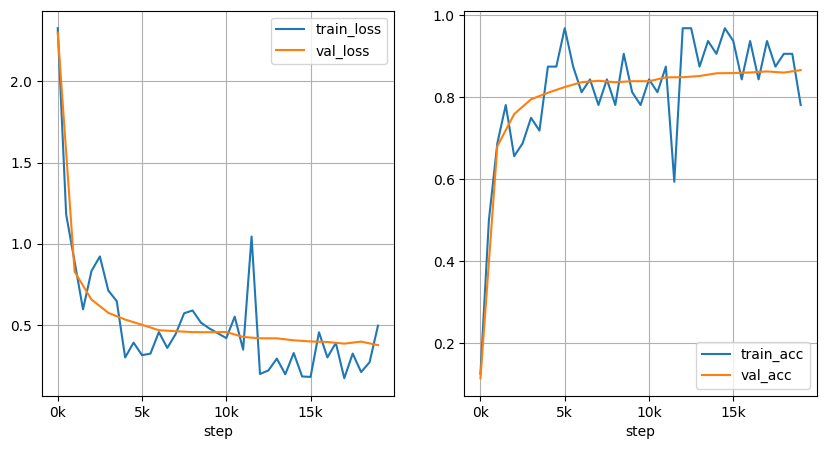

In [42]:
# 绘制学习曲线函数：可视化训练集和验证集的损失与准确率随训练步数的变化趋势
# 注意：损失值不一定在 [0, 1] 范围内，取值范围由损失函数和数据分布决定
def plot_learning_curves(record_dict, sample_step=500):
    """
    绘制训练/验证集的损失曲线和准确率曲线（学习曲线）。

    参数：
        record_dict (dict): training() 返回的训练记录字典，包含 "train" 和 "val" 两个键
        sample_step (int):  对训练记录进行下采样的步长，默认每500步取一个点，避免训练曲线点过密
    """
    # 将训练记录列表转为 DataFrame，以 "step" 列作为行索引
    # pd.DataFrame(list[dict])：字典列表 → DataFrame，列名来自字典的键（step、loss、acc）
    # .set_index("step")：将 "step" 列设为 DataFrame 的行索引（Index 类型）
    # .iloc[::sample_step]：按步长 sample_step 进行等间隔下采样，减少绘图点数量
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]

    # 验证记录直接转为 DataFrame，无需下采样（验证本来记录就不频繁）
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 计算子图数量：等于 DataFrame 列数（loss 和 acc 两列 → 2个子图）
    fig_num = len(train_df.columns)   # int: 子图数量，通常为 2

    # 创建 1 行 fig_num 列的子图布局
    # figsize=(宽, 高)：单位英寸；每个子图宽5英寸，共 fig_num × 5 英寸
    # 返回：fig（Figure 对象）和 axs（Axes 数组，形状 [fig_num]）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    # 遍历每个指标列（如 "loss" 和 "acc"），分别在对应子图中绘制曲线
    for idx, item in enumerate(train_df.columns):
        # idx (int): 子图索引（0 对应 loss 子图，1 对应 acc 子图）
        # item (str): 指标列名（如 "loss" 或 "acc"）

        # 绘制训练集曲线：x 轴为训练步数（DataFrame 的 index），y 轴为指标值
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")

        # 绘制验证集曲线（验证频率低于训练，因此点较稀疏）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")

        axs[idx].grid()    # 显示背景网格，便于读取具体数值
        axs[idx].legend()  # 显示图例，区分训练曲线和验证曲线

        # 设置 x 轴刻度：从 0 到最后一步，每隔 5000 步一个刻度
        # range(start, stop, step)：生成整数序列，此处生成 5000 的倍数列表
        x_data = range(0, train_df.index[-1], 5000)   # range 对象，如 [0, 5000, 10000, ...]
        axs[idx].set_xticks(x_data)   # 设置 x 轴刻度的位置

        # 将刻度标签格式化为 "xk" 形式，如 5000 → "5k"，10000 → "10k"，提升可读性
        # map(func, iterable)：对 iterable 中每个元素应用 func，返回 map 对象（惰性求值）
        # lambda x: f"{int(x/1000)}k"：将步数除以1000并添加"k"后缀
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", x_data))

        axs[idx].set_xlabel("step")   # 设置 x 轴标签为 "step"（训练步数）

    plt.show()   # 渲染并显示图表（在 notebook 中输出为内嵌图像）

# 调用函数绘制学习曲线，横坐标为训练步数（steps）
# sample_step=500：训练曲线每500步取一个数据点（验证曲线使用全部记录点）
plot_learning_curves(record, sample_step=500)

## 五、模型评估

### 5.1 实例化新模型（用于加载检查点）

In [43]:
# 重新实例化模型，用于加载已保存的最佳检查点进行最终评估
# 实际部署流程：必须先创建与训练时相同网络结构的模型对象，再通过 load_state_dict 填入参数
# 此时模型参数为随机初始化值，加载检查点后会被替换为训练好的参数
model = NeuralNetwork()       # 创建与训练时结构完全相同的 NeuralNetwork 实例

model = model.to(device)      # 将模型转移到目标设备（推理时也需要与输入数据在同一设备上）

### 5.2 加载最佳检查点并评估

In [44]:
# 模型保存方式说明：
#   方式1（完整保存，包含结构+参数）：torch.save(model, path)
#               加载：model = torch.load(path)
#   方式2（仅保存参数，推荐）：    torch.save(model.state_dict(), path)
#               加载：model.load_state_dict(torch.load(path))   ← 本项目使用此方式

# torch.load 参数说明：
#   "checkpoints/best.ckpt": 检查点文件路径（str），由 SaveCheckpointsCallback 保存
#   weights_only=True:        安全模式，只还原张量数据，不执行任意 Python 代码
#                             （PyTorch >= 2.0 强烈推荐，可防止反序列化攻击）
#   map_location="cpu":       将保存时的设备映射到 CPU，
#                             即使原模型保存在 GPU 上，加载时也能在 CPU 环境下成功读取
state_dict = torch.load("checkpoints/best.ckpt", weights_only=True, map_location="cpu")

# model.load_state_dict(state_dict)：将参数字典中的数值逐一填入模型对应参数
# strict=True（默认）：要求 state_dict 的键与模型参数名称完全匹配
model.load_state_dict(state_dict)


# 在验证集上计算最终损失和准确率
# evaluating() 内部使用 @torch.no_grad()，不计算梯度，节省内存
# 返回：(float, float) = (验证集平均损失, 验证集准确率)
loss, acc = evaluating(model, test_loader, loss_fct,optimizer)

# 格式化输出：:.4f 表示保留4位小数
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3931
accuracy: 0.8594
